# SynFS Refactored Validation Notebook
This notebook verifies the refactored SynFS implementation.

## Section A — Quick Verification

In [2]:

import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from trainer.trainer import SynFSTrainer
from data.dataset import SimpleDataset
from omegaconf import OmegaConf

print("Imports successful ✔")

def make_quick_synthetic(n_samples=200, views_dims=[20, 30]):
    X = [np.random.randn(n_samples, d).astype(np.float32) for d in views_dims]
    y = (np.random.rand(n_samples) > 0.5).astype(int)
    return X, y

views_dims = [20, 30]
X, y = make_quick_synthetic(200, views_dims)

loader = DataLoader(SimpleDataset(X, y), batch_size=32, shuffle=True)

cfg = OmegaConf.create({
    "model": {
        "views_dims": views_dims,
        "hidden_dims": [32,48],
        "output_dim":2,
        "batch_norm":True,
        "dropout":True,
        "activation": "relu",
        "learning_rate": 1e-3,
        "s_learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "s_lam": 0.1,
        "ns_lam": 0.1,
        "ns_alpha": 0.2,
    },
    "nr_epochs": 2,
    "seed": 0,
    "device": "cpu"
})

trainer = SynFSTrainer(cfg)

for epoch in range(cfg.nr_epochs):
    metrics = trainer.run_epoch(loader)
    print("Epoch", epoch, "loss =", metrics['loss'])


Imports successful ✔
Epoch 0 loss = 1.5798285560948508
Epoch 1 loss = 1.5434952463422502


## Section B — Full Reproduction

In [4]:

def make_full_synthetic(n_samples=2000, views_dims=[32, 48]):
    X = [np.random.randn(n_samples, d).astype(np.float32) for d in views_dims]
    latent = 0.7 * X[0][:, :3].sum(axis=1) + 0.3 * X[1][:, :5].sum(axis=1)
    y = (latent + np.random.randn(n_samples) * 0.5 > 0).astype(int)
    return X, y

views_dims = [32, 48]
X, y = make_full_synthetic(2000, views_dims)

idx = np.arange(len(y))
np.random.shuffle(idx)
split = int(0.8 * len(y))
train_idx, val_idx = idx[:split], idx[split:]

tr_X = [v[train_idx] for v in X]
va_X = [v[val_idx] for v in X]
tr_y = y[train_idx]
va_y = y[val_idx]

train_loader = DataLoader(SimpleDataset(tr_X, tr_y), batch_size=64, shuffle=True)
val_loader   = DataLoader(SimpleDataset(va_X, va_y), batch_size=128)

cfg = OmegaConf.create({
    "model": {
        "views_dims": views_dims,
        "hidden_dims": [32, 32], 
        "output_dim":2,
        "batch_norm":True,
        "dropout":True,
        "activation": "relu",
        "learning_rate": 1e-3,
        "s_learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "s_lam": 0.1,
        "ns_lam": 0.1,
        "ns_alpha": 0.2,
    },
    "nr_epochs": 90,
    "seed": 0,
    "device": "cpu"
})

trainer = SynFSTrainer(cfg)

history = {"train_loss": [], "val_auroc": []}

for epoch in range(cfg.nr_epochs):
    train_metrics = trainer.run_epoch(train_loader)
    val_metrics   = trainer.run_val(val_loader)

    history["train_loss"].append(train_metrics["loss"])
    history["val_auroc"].append(val_metrics["auroc"])

    print("Epoch", epoch, "Train Loss:", train_metrics['loss'], "Val AUROC:", val_metrics['auroc'])


/Users/choheekim/SynFS/src/trainer/trainer.py:351: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  all_losses.append(float(ai_loss))


Epoch 0 Train Loss: 1.378531483411789 Val AUROC: 0.0
Epoch 1 Train Loss: 1.3407423382997512 Val AUROC: 0.0
Epoch 2 Train Loss: 1.288251114487648 Val AUROC: 0.0
Epoch 3 Train Loss: 1.2615477764606475 Val AUROC: 0.0
Epoch 4 Train Loss: 1.2449788063764573 Val AUROC: 0.0
Epoch 5 Train Loss: 1.2235181194543838 Val AUROC: 0.0
Epoch 6 Train Loss: 1.1883659023046493 Val AUROC: 0.0
Epoch 7 Train Loss: 1.1653426313400268 Val AUROC: 0.0
Epoch 8 Train Loss: 1.1307049790024757 Val AUROC: 0.0
Epoch 9 Train Loss: 1.110186606347561 Val AUROC: 0.0
Epoch 10 Train Loss: 1.081341018974781 Val AUROC: 0.0
Epoch 11 Train Loss: 1.0597118788957596 Val AUROC: 0.0
Epoch 12 Train Loss: 1.0476171040534974 Val AUROC: 0.0
Epoch 13 Train Loss: 1.0231527391076087 Val AUROC: 0.0
Epoch 14 Train Loss: 1.0127485662698745 Val AUROC: 0.0
Epoch 15 Train Loss: 1.005063377916813 Val AUROC: 0.0
Epoch 16 Train Loss: 0.9978643330931664 Val AUROC: 0.0
Epoch 17 Train Loss: 0.9835399653017521 Val AUROC: 0.0
Epoch 18 Train Loss: 0.96

## Gate Visualization

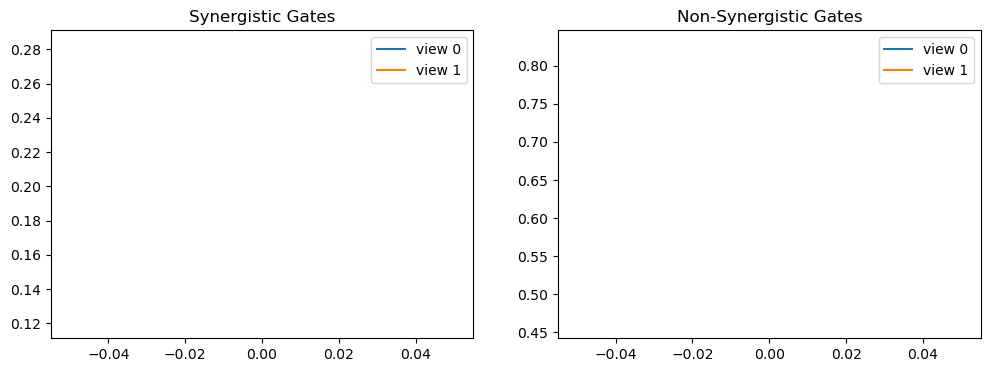

In [6]:

s_gates = [
    sel.hard_sigmoid(sel.mu.detach()).cpu().numpy()
    for sel in trainer.model.s_model.s_selectors
]

n_gates = [
    sel.hard_sigmoid(sel.mu.detach()).cpu().numpy()
    for sel in trainer.model.ns_model.s_selectors
]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Synergistic Gates")
for i, g in enumerate(s_gates):
    plt.plot(g.mean(axis=0), label=f"view {i}")
plt.legend()

plt.subplot(1,2,2)
plt.title("Non-Synergistic Gates")
for i, g in enumerate(n_gates):
    plt.plot(g.mean(axis=0), label=f"view {i}")
plt.legend()

plt.show()
